# Conversational Dynamics — Dyad 2 (Piper vs Cloudy)
**Nature Communications-level pipeline** | Single-dyad analysis across two conditions

**Data source**: Structured transcript files (`.txt`) — `Question_N` sections with `SPEAKER_XX: text` format.

**Sections**
1. Configuration (set order mode here)
2. Data Loading & Descriptives
3. Turn-Taking Dynamics
4. Speaking Balance & Lexical Diversity
5. Linguistic Alignment
6. Cross-Condition Comparison
7. Question-Level Progression
8. Broader Dataset Context
9. Summary


## 0. Imports & Style

In [1]:
import warnings; warnings.filterwarnings('ignore')
import re, os
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Nature Communications rcParams
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.frameon': False,
    'legend.fontsize': 8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

# Fixed condition colours (by condition name, regardless of order)
COND_PAL = {'piper': '#4878CF', 'cloudy': '#D65F5F'}
Q_ORDER  = ['Question_1', 'Question_2', 'Question_3']
print('Imports OK')

Imports OK


## 1. Configuration

### File paths

In [2]:
FILE_PIPER  = '/Users/Meihui/Downloads/sync/CVS/recording/all_srt/piper/dyad2_250429_piper_discussion.txt'
FILE_CLOUDY = '/Users/Meihui/Downloads/sync/CVS/recording/all_srt/cloudy/dyad2_250429_cloudy_discussion.txt'
MODELS_DIR  = '/Users/Meihui/Downloads/sync/CVS/cvs_v1/'
MIN_WORDS   = 5
SEED        = 42

### Viewing-order configuration

**`WATCH_ORDER`** — the actual sequence in which the dyad watched the clips (first → last). Here: cloudy was watched first, piper second.

**`ORDER_MATTERS`** — controls how results are displayed and labelled:

| `ORDER_MATTERS` | Display order | Labels |
|---|---|---|
| `True` | Watching sequence (cloudy → piper) | *Session 1 (Cloudy)*, *Session 2 (Piper)* |
| `False` | Alphabetical (cloudy → piper) | *Cloudy*, *Piper* |

In [3]:
# ─── SET THESE TWO VARIABLES ───────────────────────────────────────────────
WATCH_ORDER   = ['cloudy', 'piper']   # actual viewing sequence, first to last
ORDER_MATTERS = True                   # True = sequence mode | False = condition mode
# ────────────────────────────────────────────────────────────────────────────

# Derived display settings — do not edit below this line
DISPLAY_ORDER = WATCH_ORDER if ORDER_MATTERS else sorted(WATCH_ORDER)

if ORDER_MATTERS:
    DISPLAY_LABELS = {
        c: f'Sess {i+1} ({c.capitalize()})'
        for i, c in enumerate(WATCH_ORDER)
    }
    mode_note = 'Sequence mode: conditions labelled by watch order'
else:
    DISPLAY_LABELS = {c: c.capitalize() for c in DISPLAY_ORDER}
    mode_note = 'Condition mode: conditions labelled by name (order ignored)'

print(f'Mode        : {mode_note}')
print(f'Display order: {DISPLAY_ORDER}')
print(f'Labels       : {DISPLAY_LABELS}')

Mode        : Sequence mode: conditions labelled by watch order
Display order: ['cloudy', 'piper']
Labels       : {'cloudy': 'Sess 1 (Cloudy)', 'piper': 'Sess 2 (Piper)'}


## 2. Data Loading & Descriptives
Each transcript is parsed into question-labelled speaker turns. **Table 1** reports per-question, per-condition descriptives (shown in display order). **Fig. 1** compares word-count distributions by speaker and condition.

In [4]:
def parse_transcript(filepath):
    with open(filepath, 'r', encoding='utf-8') as fh:
        lines = fh.readlines()
    questions = {}
    cur_q, cur_turns = None, []
    for line in lines:
        line = line.strip()
        if not line:
            continue
        if re.match(r'^Question_\d+', line):
            if cur_q and cur_turns:
                questions[cur_q] = cur_turns
            cur_q, cur_turns = line, []
        else:
            m = re.match(r'^(SPEAKER_\d+|UNKNOWN):\s*(.*)', line)
            if m and m.group(2).strip():
                cur_turns.append((m.group(1), m.group(2).strip()))
    if cur_q and cur_turns:
        questions[cur_q] = cur_turns
    return questions

def to_dataframe(questions, condition):
    rows = []
    for q_label, segs in questions.items():
        for idx, (spk, text) in enumerate(segs):
            rows.append({'condition': condition, 'question': q_label,
                         'seg_id': idx, 'speaker': spk,
                         'utt': text, 'n_words': len(text.split())})
    return pd.DataFrame(rows)

q_piper  = parse_transcript(FILE_PIPER)
q_cloudy = parse_transcript(FILE_CLOUDY)

df_piper  = to_dataframe(q_piper,  'piper')
df_cloudy = to_dataframe(q_cloudy, 'cloudy')
df = pd.concat([df_piper, df_cloudy], ignore_index=True)

print(f'Piper  — {len(q_piper)} questions, {len(df_piper)} segments')
print(f'Cloudy — {len(q_cloudy)} questions, {len(df_cloudy)} segments')

Piper  — 3 questions, 141 segments
Cloudy — 3 questions, 175 segments


In [5]:
# Table 1: Descriptives in DISPLAY_ORDER
rows = []
for cond in DISPLAY_ORDER:
    for q in Q_ORDER:
        sub = df[(df.condition == cond) & (df.question == q)]
        if len(sub) == 0:
            continue
        rows.append({
            'Condition':   DISPLAY_LABELS[cond],
            'Question':    q,
            'Segments':    len(sub),
            'SP00 segs':   (sub.speaker == 'SPEAKER_00').sum(),
            'SP01 segs':   (sub.speaker == 'SPEAKER_01').sum(),
            'Words total': sub.n_words.sum(),
            'Words/seg':   round(sub.n_words.mean(), 1),
        })
tbl1 = pd.DataFrame(rows)
print('Table 1. Segment-level descriptives (displayed in:', ', '.join(DISPLAY_LABELS[c] for c in DISPLAY_ORDER), ')')
print(tbl1.to_string(index=False))

Table 1. Segment-level descriptives (displayed in: Sess 1 (Cloudy), Sess 2 (Piper) )
      Condition   Question  Segments  SP00 segs  SP01 segs  Words total  Words/seg
Sess 1 (Cloudy) Question_1        61         28         33          480        7.9
Sess 1 (Cloudy) Question_2        47         19         28          494       10.5
Sess 1 (Cloudy) Question_3        67         24         42          688       10.3
 Sess 2 (Piper) Question_1        59         26         33          500        8.5
 Sess 2 (Piper) Question_2        47         25         22          521       11.1
 Sess 2 (Piper) Question_3        35         15         20          518       14.8


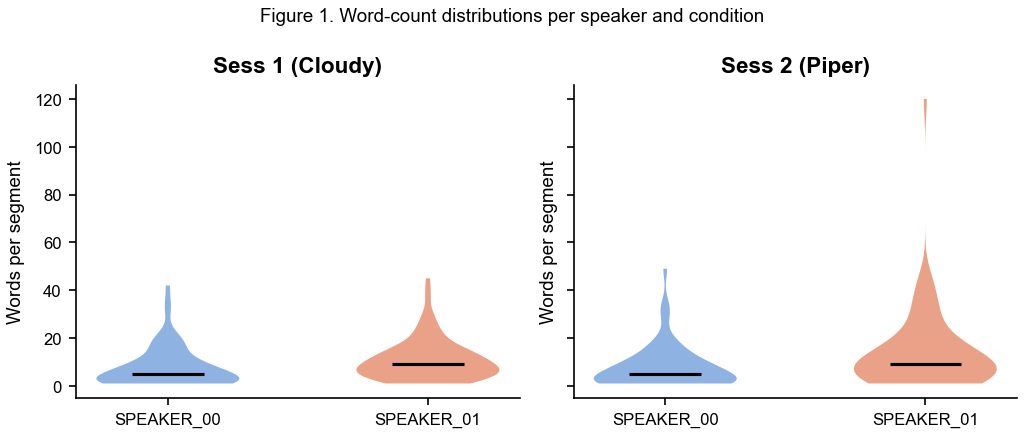

Fig 1 saved.


In [6]:
# Fig 1: Word-count distribution — panels in DISPLAY_ORDER
fig, axes = plt.subplots(1, 2, figsize=(7, 3), sharey=True)
for ax, cond in zip(axes, DISPLAY_ORDER):
    sub   = df[df.condition == cond]
    data  = [sub[sub.speaker == sp]['n_words'].values
             for sp in ['SPEAKER_00', 'SPEAKER_01']]
    parts = ax.violinplot(data, positions=[0, 1], widths=0.55,
                          showmedians=True, showextrema=False)
    for patch, color in zip(parts['bodies'], ['#5f93d6', '#e07b54']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['SPEAKER_00', 'SPEAKER_01'])
    ax.set_ylabel('Words per segment')
    ax.set_title(DISPLAY_LABELS[cond], fontweight='bold')
fig.suptitle('Figure 1. Word-count distributions per speaker and condition', fontsize=9)
plt.tight_layout()
plt.savefig('fig1_word_counts.pdf')
plt.show()
print('Fig 1 saved.')

## 3. Turn-Taking Dynamics
Consecutive utterance segments by the same speaker are collapsed into a single **turn**.

**Switch rate** is computed at the **segment level** (before merging) — the proportion of adjacent raw diariser lines that change speaker. This gives a meaningful measure of back-and-forth frequency unaffected by the merging step.

Metrics: **segment-level switch rate**, **total turns** (post-merge), **mean turn length** (words). **Fig. 2** shows per-question values in display order.

In [7]:
def build_turns(segments):
    turns = []
    i = 0
    while i < len(segments):
        spk, txt = segments[i]
        texts = [txt]
        j = i + 1
        while j < len(segments) and segments[j][0] == spk:
            texts.append(segments[j][1])
            j += 1
        turns.append({'speaker': spk, 'utt': ' '.join(texts),
                      'n_words': sum(len(t.split()) for t in texts),
                      'n_segs': j - i})
        i = j
    return turns

def turn_metrics(questions_dict, condition):
    rows = []
    for q_label, segs in questions_dict.items():
        # Segment-level switch rate (before merging)
        n_segs = len(segs)
        seg_switches = sum(segs[i][0] != segs[i-1][0] for i in range(1, n_segs))
        seg_switch_rate = round(seg_switches / (n_segs - 1), 3) if n_segs > 1 else np.nan

        turns   = build_turns(segs)
        spk_seq = [t['speaker'] for t in turns]
        n       = len(spk_seq)
        if n < 2:
            continue
        rows.append({'condition': condition, 'question': q_label,
                     'n_turns': n,
                     'seg_switch_rate': seg_switch_rate,
                     'mean_turn_words': round(np.mean([t['n_words'] for t in turns]), 1),
                     'sp01_turns': sum(1 for s in spk_seq if s == 'SPEAKER_01'),
                     'sp00_turns': sum(1 for s in spk_seq if s == 'SPEAKER_00')})
    return pd.DataFrame(rows)

tt_piper  = turn_metrics(q_piper,  'piper')
tt_cloudy = turn_metrics(q_cloudy, 'cloudy')
tt = pd.concat([tt_piper, tt_cloudy], ignore_index=True)
print('Turn-taking (displayed in order:', ', '.join(DISPLAY_LABELS[c] for c in DISPLAY_ORDER), ')')
display_tt = tt.copy()
display_tt['Condition'] = display_tt['condition'].map(DISPLAY_LABELS)
print(display_tt[['Condition','question','n_turns','seg_switch_rate','mean_turn_words']].to_string(index=False))

Turn-taking (displayed in order: Sess 1 (Cloudy), Sess 2 (Piper) )
      Condition   question  n_turns  seg_switch_rate  mean_turn_words
 Sess 2 (Piper) Question_1       38            0.638             13.2
 Sess 2 (Piper) Question_2       28            0.587             18.6
 Sess 2 (Piper) Question_3       24            0.676             21.6
Sess 1 (Cloudy) Question_1       34            0.550             14.1
Sess 1 (Cloudy) Question_2       20            0.413             24.7
Sess 1 (Cloudy) Question_3       35            0.515             19.7


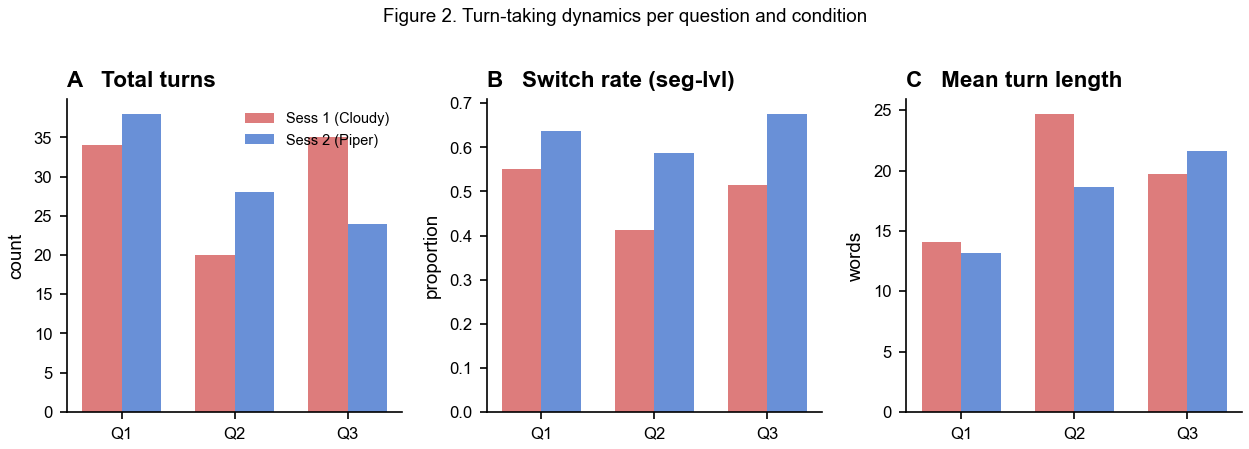

Fig 2 saved.


In [8]:
# Fig 2: Turn-taking metrics — bars in DISPLAY_ORDER
tt_cols = [
    ('n_turns',          'Total turns',          'count'),
    ('seg_switch_rate',  'Switch rate (seg-lvl)', 'proportion'),
    ('mean_turn_words',  'Mean turn length',      'words'),
]
fig, axes = plt.subplots(1, 3, figsize=(8.5, 3))
x = np.arange(len(Q_ORDER))
bar_w = 0.35
for ax, (col, label, unit), letter in zip(axes, tt_cols, 'ABC'):
    for i, cond in enumerate(DISPLAY_ORDER):
        sub  = tt[tt.condition == cond].set_index('question')
        vals = [sub.loc[q, col] if q in sub.index else 0 for q in Q_ORDER]
        ax.bar(x + (i - 0.5) * bar_w, vals, bar_w,
               label=DISPLAY_LABELS[cond], color=COND_PAL[cond], alpha=0.82)
    ax.set_xticks(x)
    ax.set_xticklabels(['Q1', 'Q2', 'Q3'])
    ax.set_ylabel(unit)
    ax.set_title(f'{letter}   {label}', loc='left', fontweight='bold')
    if letter == 'A':
        ax.legend(fontsize=7)
fig.suptitle('Figure 2. Turn-taking dynamics per question and condition', fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig('fig2_turn_taking.pdf')
plt.show()
print('Fig 2 saved.')

## 4. Speaking Balance & Lexical Diversity
**SPEAKER_01 word %** (verbal dominance) and **type-token ratio (TTR)** per question × condition. **Fig. 3** visualises these metrics in display order.

In [9]:
def speaking_balance(questions_dict, condition):
    rows = []
    for q_label, segs in questions_dict.items():
        sp00 = [(spk, t) for spk, t in segs if spk == 'SPEAKER_00']
        sp01 = [(spk, t) for spk, t in segs if spk == 'SPEAKER_01']
        w00  = sum(len(t.split()) for _, t in sp00)
        w01  = sum(len(t.split()) for _, t in sp01)
        tot  = w00 + w01
        p01  = w01 / tot * 100 if tot > 0 else 50.0
        def ttr(texts):
            words = ' '.join(texts).lower().split()
            return len(set(words)) / len(words) if words else np.nan
        ttr00 = ttr([t for _, t in sp00])
        ttr01 = ttr([t for _, t in sp01])
        rows.append({'condition': condition, 'question': q_label,
                     'sp01_word_pct': round(p01, 1),
                     'sp00_word_pct': round(100 - p01, 1),
                     'ttr_00': round(ttr00, 3), 'ttr_01': round(ttr01, 3),
                     'total_words': tot,
                     'words_sp00': w00, 'words_sp01': w01})
    return pd.DataFrame(rows)

bal_piper  = speaking_balance(q_piper,  'piper')
bal_cloudy = speaking_balance(q_cloudy, 'cloudy')
bal = pd.concat([bal_piper, bal_cloudy], ignore_index=True)
display_bal = bal.copy()
display_bal['Condition'] = display_bal['condition'].map(DISPLAY_LABELS)
print('Speaking balance (displayed in order:', ', '.join(DISPLAY_LABELS[c] for c in DISPLAY_ORDER), ')')
print(display_bal[['Condition','question','sp01_word_pct','ttr_00','ttr_01']].to_string(index=False))

Speaking balance (displayed in order: Sess 1 (Cloudy), Sess 2 (Piper) )
      Condition   question  sp01_word_pct  ttr_00  ttr_01
 Sess 2 (Piper) Question_1           68.0   0.606   0.491
 Sess 2 (Piper) Question_2           58.9   0.575   0.528
 Sess 2 (Piper) Question_3           74.3   0.617   0.442
Sess 1 (Cloudy) Question_1           63.1   0.582   0.515
Sess 1 (Cloudy) Question_2           70.0   0.635   0.454
Sess 1 (Cloudy) Question_3           68.1   0.534   0.425


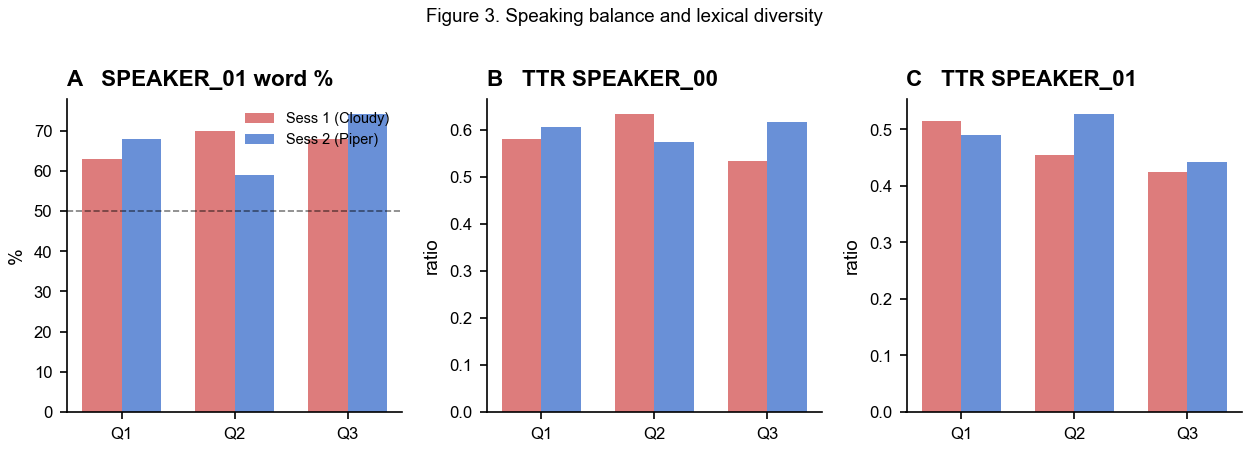

Fig 3 saved.


In [10]:
# Fig 3: Speaking balance — bars in DISPLAY_ORDER
bal_cols = [
    ('sp01_word_pct', 'SPEAKER_01 word %', '%'),
    ('ttr_00',        'TTR SPEAKER_00',    'ratio'),
    ('ttr_01',        'TTR SPEAKER_01',    'ratio'),
]
fig, axes = plt.subplots(1, 3, figsize=(8.5, 3))
x = np.arange(len(Q_ORDER))
bar_w = 0.35
for ax, (col, label, unit), letter in zip(axes, bal_cols, 'ABC'):
    for i, cond in enumerate(DISPLAY_ORDER):
        sub  = bal[bal.condition == cond].set_index('question')
        vals = [sub.loc[q, col] if q in sub.index else np.nan for q in Q_ORDER]
        ax.bar(x + (i - 0.5) * bar_w, vals, bar_w,
               label=DISPLAY_LABELS[cond], color=COND_PAL[cond], alpha=0.82)
    ax.set_xticks(x)
    ax.set_xticklabels(['Q1', 'Q2', 'Q3'])
    ax.set_ylabel(unit)
    ax.set_title(f'{letter}   {label}', loc='left', fontweight='bold')
    if col == 'sp01_word_pct':
        ax.axhline(50, color='black', lw=0.8, ls='--', alpha=0.5)
    if letter == 'A':
        ax.legend(fontsize=7)
fig.suptitle('Figure 3. Speaking balance and lexical diversity', fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig('fig3_speaking_balance.pdf')
plt.show()
print('Fig 3 saved.')

## 5. Linguistic Alignment
| Metric | Level | Description |
|--------|-------|-------------|
| **Jaccard** | Lexical | Token-set overlap between speakers |
| **LSM** | Stylistic | Linguistic Style Matching (7 LIWC function-word categories) |
| **TF-IDF cosine** | Semantic | Topic/content similarity |

**Fig. 4** compares all three metrics in display order.

In [11]:
def tokenize(text):
    return re.findall(r'[a-z]+', text.lower()) if text else []

def jaccard(text_a, text_b):
    a, b = set(tokenize(text_a)), set(tokenize(text_b))
    if not a or not b:
        return np.nan
    return round(len(a & b) / len(a | b), 4)

FW = {
    'ppron':   {'i','me','my','mine','myself','we','us','our','ours','ourselves',
                'you','your','yours','yourself','he','him','his','she','her','hers',
                'they','them','their','theirs'},
    'ipron':   {'it','its','itself','this','that','these','those','what','which',
                'who','whom','whose'},
    'article': {'a','an','the'},
    'prep':    {'above','across','after','against','along','among','around','at',
                'before','behind','below','beside','between','by','down','during',
                'for','from','in','into','near','of','off','on','out','over','past',
                'since','through','to','toward','under','until','up','with','within'},
    'conj':    {'and','but','or','nor','so','yet','although','because','before',
                'if','since','though','unless','until','when','while'},
    'negate':  {'no','not','never','nothing','nobody','none','neither'},
    'auxverb': {'am','is','are','was','were','be','been','being',
                'have','has','had','do','does','did','will','would',
                'shall','should','may','might','must','can','could'},
}

def lsm(text_a, text_b):
    wa, wb = tokenize(text_a), tokenize(text_b)
    if len(wa) < MIN_WORDS or len(wb) < MIN_WORDS:
        return np.nan
    vals = []
    for fw_set in FW.values():
        pa = sum(w in fw_set for w in wa) / len(wa)
        pb = sum(w in fw_set for w in wb) / len(wb)
        vals.append(1 - abs(pa - pb) / (pa + pb + 1e-6))
    return round(float(np.mean(vals)), 4)

def alignment_metrics(questions_dict, condition):
    rows = []
    for q_label, segs in questions_dict.items():
        s00 = ' '.join(t for spk, t in segs if spk == 'SPEAKER_00')
        s01 = ' '.join(t for spk, t in segs if spk == 'SPEAKER_01')
        rows.append({'condition': condition, 'question': q_label,
                     'jaccard': jaccard(s00, s01), 'lsm': lsm(s00, s01),
                     'text_sp00': s00, 'text_sp01': s01})
    return pd.DataFrame(rows)

al_piper  = alignment_metrics(q_piper,  'piper')
al_cloudy = alignment_metrics(q_cloudy, 'cloudy')
al = pd.concat([al_piper, al_cloudy], ignore_index=True)
try:
    vect = TfidfVectorizer(max_features=500)
    all_texts = al['text_sp00'].tolist() + al['text_sp01'].tolist()
    mat = vect.fit_transform(all_texts)
    n   = len(al)
    al['semantic_sim'] = [cosine_similarity(mat[i], mat[i + n])[0, 0] for i in range(n)]
except Exception as e:
    print(f'TF-IDF failed: {e}')
    al['semantic_sim'] = np.nan
display_al = al.copy()
display_al['Condition'] = display_al['condition'].map(DISPLAY_LABELS)
print('Alignment metrics (order:', ', '.join(DISPLAY_LABELS[c] for c in DISPLAY_ORDER), ')')
print(display_al[['Condition','question','jaccard','lsm','semantic_sim']].to_string(index=False))

Alignment metrics (order: Sess 1 (Cloudy), Sess 2 (Piper) )
      Condition   question  jaccard    lsm  semantic_sim
 Sess 2 (Piper) Question_1   0.2609 0.8370      0.477654
 Sess 2 (Piper) Question_2   0.2995 0.8174      0.553901
 Sess 2 (Piper) Question_3   0.2747 0.8245      0.484278
Sess 1 (Cloudy) Question_1   0.3034 0.7546      0.575081
Sess 1 (Cloudy) Question_2   0.2529 0.7583      0.533986
Sess 1 (Cloudy) Question_3   0.2788 0.8911      0.565753


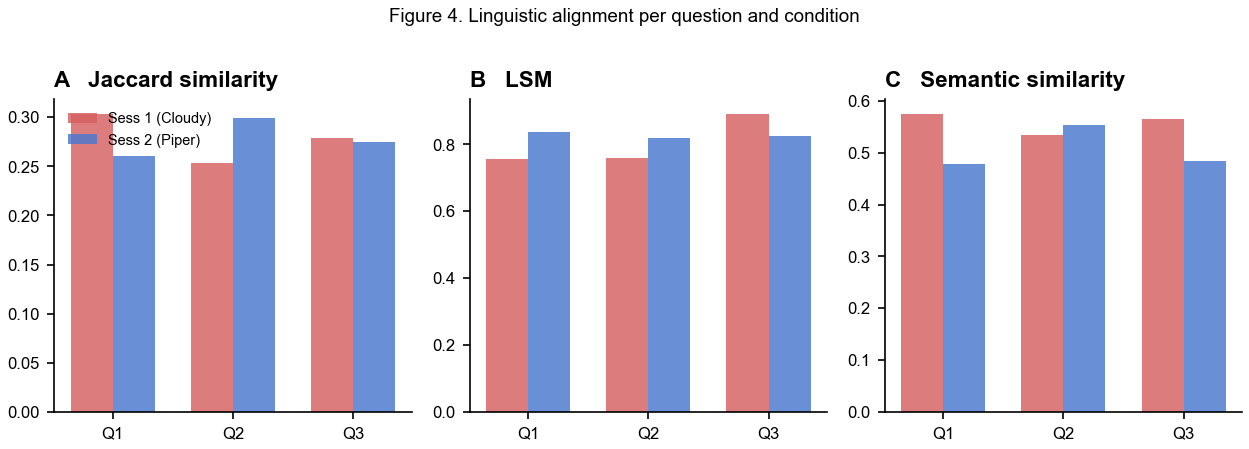

Fig 4 saved.


In [12]:
# Fig 4: Alignment — bars in DISPLAY_ORDER
align_cols = [
    ('jaccard',      'Jaccard similarity'),
    ('lsm',          'LSM'),
    ('semantic_sim', 'Semantic similarity'),
]
fig, axes = plt.subplots(1, 3, figsize=(8.5, 3))
x = np.arange(len(Q_ORDER))
bar_w = 0.35
for ax, (col, label), letter in zip(axes, align_cols, 'ABC'):
    for i, cond in enumerate(DISPLAY_ORDER):
        sub  = al[al.condition == cond].set_index('question')
        vals = [sub.loc[q, col] if q in sub.index else np.nan for q in Q_ORDER]
        ax.bar(x + (i - 0.5) * bar_w, vals, bar_w,
               label=DISPLAY_LABELS[cond], color=COND_PAL[cond], alpha=0.82)
    ax.set_xticks(x)
    ax.set_xticklabels(['Q1', 'Q2', 'Q3'])
    ax.set_title(f'{letter}   {label}', loc='left', fontweight='bold')
    if letter == 'A':
        ax.legend(fontsize=7)
fig.suptitle('Figure 4. Linguistic alignment per question and condition', fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig('fig4_alignment.pdf')
plt.show()
print('Fig 4 saved.')

## 6. Cross-Condition Comparison
Session-aggregated metrics compared between conditions. In **sequence mode**, Delta = Session 2 − Session 1 (piper − cloudy). In **condition mode**, Delta = Piper − Cloudy. **Fig. 5** shows per-question profiles in display order.

In [13]:
# Merge all session-level metrics
metric_cols = ['n_turns','seg_switch_rate','mean_turn_words',
               'sp01_word_pct','ttr_00','ttr_01','jaccard','lsm','semantic_sim']

session = (
    tt[['condition','question','n_turns','seg_switch_rate','mean_turn_words']]
    .merge(bal[['condition','question','sp01_word_pct','ttr_00','ttr_01']], on=['condition','question'])
    .merge(al[['condition','question','jaccard','lsm','semantic_sim']],     on=['condition','question'])
)

# Reference and comparison in display order
cond_a, cond_b = DISPLAY_ORDER[0], DISPLAY_ORDER[1]
label_a, label_b = DISPLAY_LABELS[cond_a], DISPLAY_LABELS[cond_b]

rows = []
for col in metric_cols:
    va = session[session.condition == cond_a][col].values
    vb = session[session.condition == cond_b][col].values
    rows.append({
        'Metric':                col,
        f'{label_a} mean (SD)': f'{np.nanmean(va):.2f} ({np.nanstd(va):.2f})',
        f'{label_b} mean (SD)': f'{np.nanmean(vb):.2f} ({np.nanstd(vb):.2f})',
        f'Delta ({label_b}-{label_a})': round(np.nanmean(vb) - np.nanmean(va), 3),
    })
tbl2 = pd.DataFrame(rows)
print(f'Table 2. Cross-condition comparison: {label_a} vs {label_b}')
print(tbl2.to_string(index=False))

Table 2. Cross-condition comparison: Sess 1 (Cloudy) vs Sess 2 (Piper)
         Metric Sess 1 (Cloudy) mean (SD) Sess 2 (Piper) mean (SD)  Delta (Sess 2 (Piper)-Sess 1 (Cloudy))
        n_turns              29.67 (6.85)             30.00 (5.89)                                   0.333
seg_switch_rate               0.49 (0.06)              0.63 (0.04)                                   0.141
mean_turn_words              19.50 (4.33)             17.80 (3.48)                                  -1.700
  sp01_word_pct              67.07 (2.91)             67.07 (6.32)                                   0.000
         ttr_00               0.58 (0.04)              0.60 (0.02)                                   0.016
         ttr_01               0.46 (0.04)              0.49 (0.04)                                   0.022
        jaccard               0.28 (0.02)              0.28 (0.02)                                   0.000
            lsm               0.80 (0.06)              0.83 (0.01)       

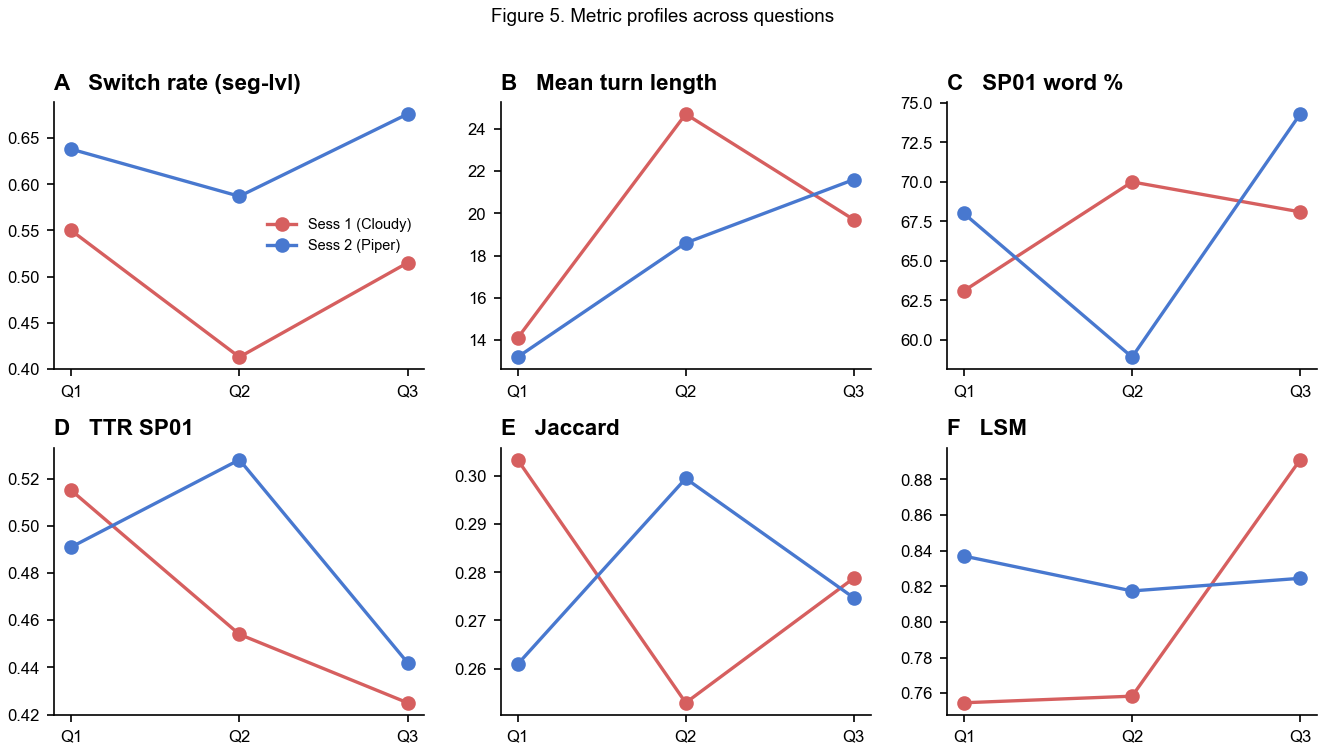

Fig 5 saved.


In [14]:
# Fig 5: Per-question line profiles in DISPLAY_ORDER
plot_cols = [
    ('seg_switch_rate', 'Switch rate (seg-lvl)'),
    ('mean_turn_words', 'Mean turn length'),
    ('sp01_word_pct',   'SP01 word %'),
    ('ttr_01',          'TTR SP01'),
    ('jaccard',         'Jaccard'),
    ('lsm',             'LSM'),
]
fig, axes = plt.subplots(2, 3, figsize=(9, 5))
axes_flat = axes.flatten()
for ax, (col, label), letter in zip(axes_flat, plot_cols, 'ABCDEF'):
    for cond in DISPLAY_ORDER:
        sub  = session[session.condition == cond].set_index('question')
        vals = [sub.loc[q, col] if q in sub.index else np.nan for q in Q_ORDER]
        ax.plot([1, 2, 3], vals, marker='o', ms=6, lw=1.6,
                color=COND_PAL[cond], label=DISPLAY_LABELS[cond])
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Q1', 'Q2', 'Q3'])
    ax.set_title(f'{letter}   {label}', loc='left', fontweight='bold')
    if letter == 'A':
        ax.legend(fontsize=7)
fig.suptitle('Figure 5. Metric profiles across questions', fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig('fig5_condition_profiles.pdf')
plt.show()
print('Fig 5 saved.')

## 7. Question-Level Progression
Δ = Q3 − Q1 shows the direction of change within each session. In **sequence mode**, bars are ordered Session 1 → Session 2, making it easy to see whether the second viewing session changed the trajectory. **Fig. 6** compares within-session trajectories.

In [15]:
delta_rows = []
for cond in DISPLAY_ORDER:
    sub = session[session.condition == cond].set_index('question')
    row = {'condition': cond, 'label': DISPLAY_LABELS[cond]}
    for col in metric_cols:
        try:
            row[col + '_delta'] = round(sub.loc['Question_3', col] - sub.loc['Question_1', col], 3)
        except Exception:
            row[col + '_delta'] = np.nan
    delta_rows.append(row)
delta = pd.DataFrame(delta_rows)
print('Within-session trajectory delta = Q3 - Q1 (order:', ', '.join(DISPLAY_LABELS[c] for c in DISPLAY_ORDER), ')')
print(delta.drop(columns=['condition']).to_string(index=False))

Within-session trajectory delta = Q3 - Q1 (order: Sess 1 (Cloudy), Sess 2 (Piper) )
          label  n_turns_delta  seg_switch_rate_delta  mean_turn_words_delta  sp01_word_pct_delta  ttr_00_delta  ttr_01_delta  jaccard_delta  lsm_delta  semantic_sim_delta
Sess 1 (Cloudy)              1                 -0.035                    5.6                  5.0        -0.048        -0.090         -0.025      0.136              -0.009
 Sess 2 (Piper)            -14                  0.038                    8.4                  6.3         0.011        -0.049          0.014     -0.012               0.007


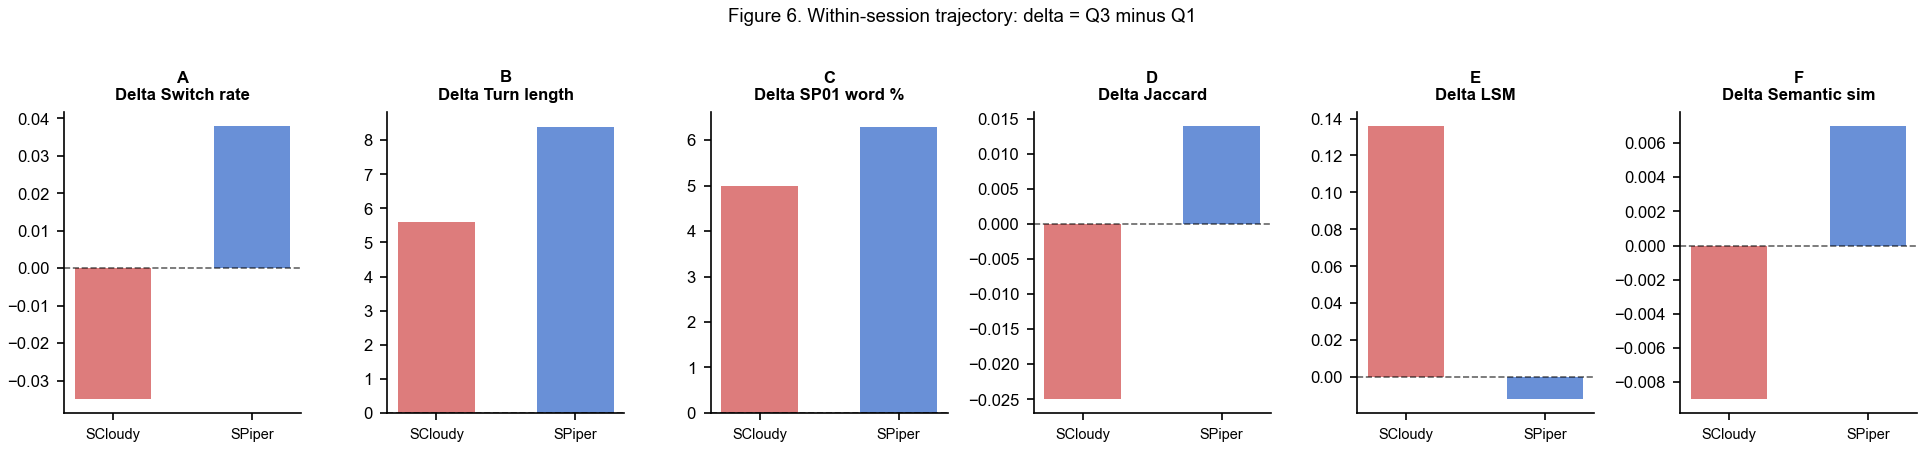

Fig 6 saved.


In [16]:
# Fig 6: Delta bars in DISPLAY_ORDER
delta_show = [
    ('seg_switch_rate_delta', 'Delta Switch rate'),
    ('mean_turn_words_delta', 'Delta Turn length'),
    ('sp01_word_pct_delta',   'Delta SP01 word %'),
    ('jaccard_delta',         'Delta Jaccard'),
    ('lsm_delta',             'Delta LSM'),
    ('semantic_sim_delta',    'Delta Semantic sim'),
]
fig, axes = plt.subplots(1, 6, figsize=(13, 3))
for ax, (col, label), letter in zip(axes, delta_show, 'ABCDEF'):
    vals   = [delta[delta.condition == c][col].values[0] for c in DISPLAY_ORDER]
    labels = [DISPLAY_LABELS[c] for c in DISPLAY_ORDER]
    colors = [COND_PAL[c] for c in DISPLAY_ORDER]
    ax.bar([0, 1], vals, color=colors, alpha=0.82, width=0.55)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)
    ax.set_xticks([0, 1])
    short = [lb.split(' ')[0][0] + lb.split('(')[-1].replace(')','') if '(' in lb else lb[:3]
             for lb in labels]
    ax.set_xticklabels(short, fontsize=7)
    ax.set_title(f'{letter}\n{label}', loc='center', fontweight='bold', fontsize=8)
fig.suptitle('Figure 6. Within-session trajectory: delta = Q3 minus Q1', fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig('fig6_progression_delta.pdf')
plt.show()
print('Fig 6 saved.')

## 8. Broader Dataset Context (double check)
Pre-computed model results from all 24 dyads (`cvs_v1/`) situate Dyad 2 in the broader sample. **Fig. 7**: model *R*² and LODO *R*². **Fig. 8**: feature-importance bootstrap CIs.

In [17]:
model_res = pd.read_csv(os.path.join(MODELS_DIR, 'model_results.csv'))
lodo_res  = pd.read_csv(os.path.join(MODELS_DIR, 'lodo_results.csv'))
perm_res  = pd.read_csv(os.path.join(MODELS_DIR, 'permutation_tests.csv'))
boot_ci   = pd.read_csv(os.path.join(MODELS_DIR, 'bootstrap_ci.csv'))
print('model_results:', model_res.columns.tolist())
print(model_res.to_string(index=False))

model_results: ['outcome', 'model', 'r2', 'r2_adj', 'aic', 'bic', 'f_stat', 'f_pval', 'cohens_f2', 'alpha', 'n_selected']
             outcome model       r2   r2_adj        aic        bic   f_stat   f_pval  cohens_f2  alpha  n_selected
           enjoyment   OLS 0.593692 0.285458 178.263413 223.142018 1.926108 0.049299   1.461185    NaN         NaN
           enjoyment Ridge 0.593350      NaN        NaN        NaN      NaN      NaN   1.459115    1.0         NaN
           enjoyment LASSO 0.503849      NaN        NaN        NaN      NaN      NaN   1.015515    0.1        12.0
           enjoyment   LME 0.842737      NaN        NaN        NaN      NaN      NaN   5.358764    NaN         NaN
coviewing_preference   OLS 0.628288 0.346300 159.337791 204.216397 2.228068 0.022082   1.690258    NaN         NaN
coviewing_preference Ridge 0.626556      NaN        NaN        NaN      NaN      NaN   1.677781    1.0         NaN
coviewing_preference LASSO 0.479411      NaN        NaN        NaN      N

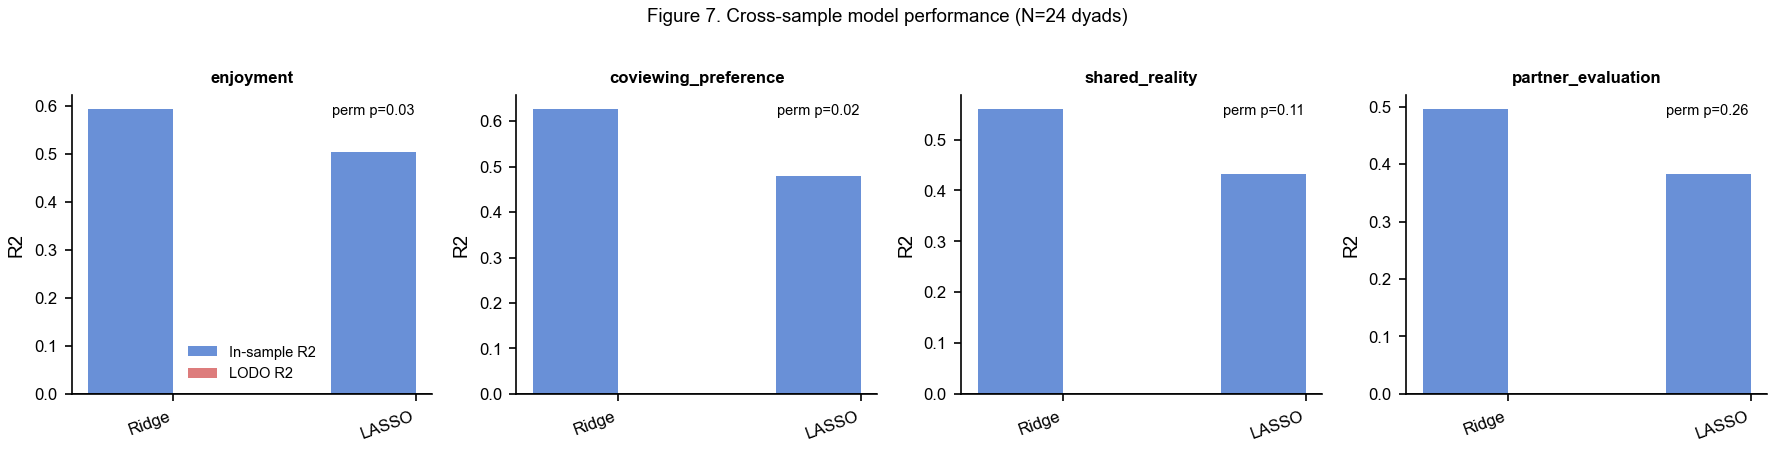

Fig 7 saved.


In [18]:
# Fig 7: Model performance
perf = model_res.merge(lodo_res, on=['model','outcome'], how='left')
outcomes = perf.outcome.unique().tolist()
models   = ['Ridge', 'LASSO']
if 'model' in perf.columns:
    perf = perf[perf.model.isin(models)]
fig, axes = plt.subplots(1, len(outcomes), figsize=(3 * len(outcomes), 3), sharey=False)
if len(outcomes) == 1:
    axes = [axes]
bar_w = 0.35
for ax, outcome in zip(axes, outcomes):
    sub = perf[perf.outcome == outcome]
    xi  = np.arange(len(sub))
    r2_col   = 'r2'      if 'r2'      in sub.columns else 'r2_adj'
    lodo_col = 'r2_lodo' if 'r2_lodo' in sub.columns else 'r2'
    ax.bar(xi - bar_w/2, sub[r2_col].clip(-1,1),   bar_w, label='In-sample R2',
           color='#4878CF', alpha=0.82)
    ax.bar(xi + bar_w/2, sub[lodo_col].clip(-1,1), bar_w, label='LODO R2',
           color='#D65F5F', alpha=0.82)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(xi)
    ax.set_xticklabels(sub.model.tolist(), rotation=20, ha='right')
    ax.set_title(outcome, fontweight='bold', fontsize=8)
    ax.set_ylabel('R2')
    if ax == axes[0]:
        ax.legend(fontsize=7)
    pr = perm_res[perm_res.outcome == outcome]
    if len(pr):
        ax.text(0.95, 0.97, f'perm p={pr.iloc[0]["p_value"]:.2f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=7)
fig.suptitle('Figure 7. Cross-sample model performance (N=24 dyads)', fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig('fig7_model_perf.pdf')
plt.show()
print('Fig 7 saved.')

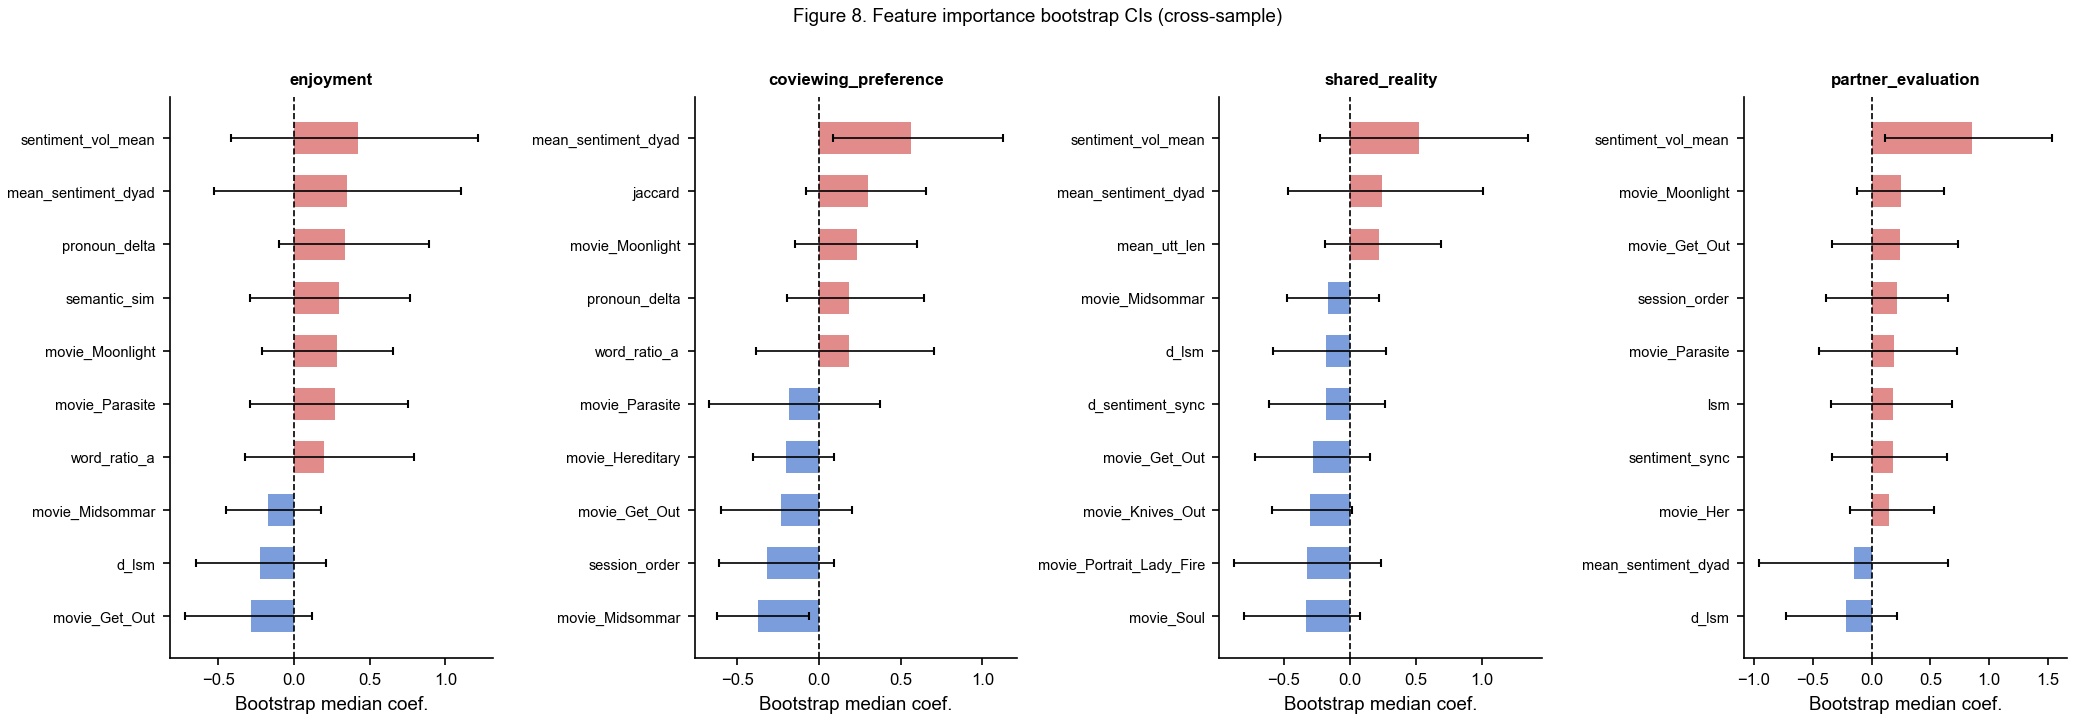

Fig 8 saved.


In [19]:
# Fig 8: Bootstrap CI feature importance
outcomes_boot = boot_ci.outcome.unique().tolist()
ncols = min(len(outcomes_boot), 4)
nrows = (len(outcomes_boot) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(3.5 * ncols, max(3, 0.4 * 10 + 0.8) * nrows))
axes_flat = np.array(axes).flatten() if hasattr(axes, '__iter__') else [axes]
for ax, outcome in zip(axes_flat, outcomes_boot):
    sub = boot_ci[boot_ci.outcome == outcome].copy()
    sub['abs_med'] = sub['boot_median'].abs()
    sub = sub.nlargest(10, 'abs_med').sort_values('boot_median')
    y   = np.arange(len(sub))
    colors = ['#D65F5F' if v > 0 else '#4878CF' for v in sub['boot_median']]
    ax.barh(y, sub['boot_median'], color=colors, alpha=0.72, height=0.6)
    ax.errorbar(sub['boot_median'], y,
                xerr=[sub['boot_median'] - sub['ci_lower'],
                      sub['ci_upper']    - sub['boot_median']],
                fmt='none', color='black', capsize=2, lw=0.8)
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_yticks(y)
    ax.set_yticklabels(sub['feature'], fontsize=7)
    ax.set_xlabel('Bootstrap median coef.')
    ax.set_title(outcome, fontweight='bold', fontsize=8)
for ax in axes_flat[len(outcomes_boot):]:
    ax.set_visible(False)
fig.suptitle('Figure 8. Feature importance bootstrap CIs (cross-sample)', fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig('fig8_feature_importance.pdf')
plt.show()
print('Fig 8 saved.')

## 9. Summary

In [20]:
print('=' * 65)
print(f'SUMMARY — DYAD 2  |  {mode_note}')
print('=' * 65)

for cond in DISPLAY_ORDER:
    lbl     = DISPLAY_LABELS[cond]
    sub_tt  = tt[tt.condition == cond]
    sub_bal = bal[bal.condition == cond]
    sub_al  = al[al.condition == cond]
    print(f'\n{lbl}')
    print(f'  Total turns (all Q)      : {sub_tt.n_turns.sum()}')
    print(f'  Avg switch rate (seg-lvl): {sub_tt.seg_switch_rate.mean():.3f}')
    print(f'  SP01 word % (mean)       : {sub_bal.sp01_word_pct.mean():.1f}%')
    print(f'  Jaccard (mean)           : {sub_al.jaccard.mean():.3f}')
    print(f'  LSM     (mean)           : {sub_al.lsm.mean():.3f}')
    print(f'  Semantic sim (mean)      : {sub_al.semantic_sim.mean():.3f}')

print(f'\nDelta ({label_b} minus {label_a}):')
va_mean = session[session.condition == cond_a][metric_cols].mean()
vb_mean = session[session.condition == cond_b][metric_cols].mean()
for col in metric_cols:
    print(f'  {col:25s}: {vb_mean[col] - va_mean[col]:+.3f}')

print('\nFigures saved: fig1-fig8 PDFs')

SUMMARY — DYAD 2  |  Sequence mode: conditions labelled by watch order

Sess 1 (Cloudy)
  Total turns (all Q)      : 89
  Avg switch rate (seg-lvl): 0.493
  SP01 word % (mean)       : 67.1%
  Jaccard (mean)           : 0.278
  LSM     (mean)           : 0.801
  Semantic sim (mean)      : 0.558

Sess 2 (Piper)
  Total turns (all Q)      : 90
  Avg switch rate (seg-lvl): 0.634
  SP01 word % (mean)       : 67.1%
  Jaccard (mean)           : 0.278
  LSM     (mean)           : 0.826
  Semantic sim (mean)      : 0.505

Delta (Sess 2 (Piper) minus Sess 1 (Cloudy)):
  n_turns                  : +0.333
  seg_switch_rate          : +0.141
  mean_turn_words          : -1.700
  sp01_word_pct            : +0.000
  ttr_00                   : +0.016
  ttr_01                   : +0.022
  jaccard                  : +0.000
  lsm                      : +0.025
  semantic_sim             : -0.053

Figures saved: fig1-fig8 PDFs
